# Sentimental project

In this notebook, we'll load train set and establish a baseline (linear) model, using simple Tf-Idf encoding.

## Environment setup

In [1]:
import re

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

## Load and examine train data

Before evaluating a baseline model, we'll load our train data and ensure no data quality
problems remain.

In [2]:
path = "../src/sentimental/data/prepared/train.csv"
data = pd.read_csv(path, names=["statement", "status"])
data.sample(10)

,statement,status
587,"There is not anything interesting about it, it...",Depression
18167,I am freaking out thinking about this and just...,Depression
1502,"Peace be upon you, O Messenger of Allah",Normal
15137,i probably havesevere gad. at least i think i ...,Stress
2162,"Moving forward is hope, Quitting is despair. R...",Anxiety
22495,babyporridge i didn t get your twitter is crap...,Normal
19232,"I have hardly ever had a GF and I am 26, I am ...",Depression
28232,"Lonely depressed dude here, ending my life in ...",Depression
10473,Suicide=peace Peace,Suicidal
946,Drowsykkkkkkkk arhhhhhhhh,Normal


In [3]:
data.duplicated().sum()

np.int64(0)

In [4]:
data["statement"].duplicated().sum()

np.int64(0)

In [5]:
data.isnull().sum()

statement    0
status       0
dtype: int64

## Preprocessing

We'll perform the following steps inside our preprocessing logic :
- Remove (or replace with placeholder)
  1. User handles (e.g. @some-user)
  2. Web addresses (starting with www. or http:// or https://)
  3. Non-ASCII or non-printable characters or sequences
  4. Unicode emojis
  5. HTML tags (e.g. &lt;br /&gt;) and special characters (e.g. &amp; or nbsp;)
  6. Encoded Unicode characters (e.g. #x200B)
  7. ASCII emoticons (e.g. :-) or (-: or ;-) and so on)

- Transform
  1. Strip hashtag prefix (#) from hashtags (e.g. #MeToo)
  2. Multi-line text quoted with double quote characters => Remove whitespace
  3. Text in all-caps => Convert to lowercase
  4. Special types of writing words (e.g. t w i t t e r instead of plain "twitter") => Find with RegEx, remove spaces (to get the actual term)

In [6]:
USER_HANDLE_RX = r"@[\S]+"
HASH_TAG_RX = r"#([\S]+)"
HTML_TAG_RX = r"<[a-zA-Z0-9\s_/='\"]+>"
HTML_OBJECT_RX = r"&?[a-z]+;"
UNICODE_OBJ_RX = r"#x[0-9a-fA-F]+;"
EXPAND_TEXT_RX = r"([a-zA-Z]\s){3,}"
WEB_URL_RX = r"((www\.[\S]+)|(https?://[\S]+))"
PUNCT_CHARS_RX = r"([\w]+)[\.?!,:;'\"]+"

In [7]:
def report_match(text, pattern):
    match = re.search(pattern, text)
    if match:
        print(f"A match was found at : {match.span()}.")
    else:
        print("Not found!")

In [8]:
def replace_expanded(match: re.Match) -> str:
    expanded = match.string[match.span()[0]:match.span()[1]]
    return expanded.replace(" ", "")

In [9]:
def clean_text(text: str) -> str:
    cleaned = text

    # Convert to lowercase
    cleaned = cleaned.lower()

    # Remove Unicode strings
    cleaned = re.sub(UNICODE_OBJ_RX, "", cleaned)

    # Remove URLs, HTML tags and HTML objects
    cleaned = re.sub(WEB_URL_RX, "", cleaned)
    cleaned = re.sub(HTML_TAG_RX, "", cleaned)
    cleaned = re.sub(HTML_OBJECT_RX, "", cleaned)

    # Remove user handles (@user)
    cleaned = re.sub(USER_HANDLE_RX, "", cleaned)

    # Remove hashtag prefix from hashtags
    cleaned = re.sub(HASH_TAG_RX, r"\1", cleaned)

    # Replace expanded text (e.g. t w i t t e r) with normal form
    cleaned = re.sub(EXPAND_TEXT_RX, replace_expanded, cleaned)

    # Remove trailing punctuation character(s) (except emoticons)
    cleaned = re.sub(PUNCT_CHARS_RX, r"\1", cleaned)

    # Replace extra whitespace and new-line with a single space
    cleaned = re.sub(r"\s+", " ", cleaned)

    # Remove tokens with non-ASCII characters (including emojis)
    cleaned = " ".join([
        word for word in cleaned.split(" ") if word.isascii()
    ])

    return cleaned

In [10]:
# This text has several parts that need cleaning. It is deliberately made up
# to test our preprocessing pipeline
msg = """
23 year old male with Lymphoma like symptoms Hi everyone!

&amp;#x200B; t w i t t e r

I have had an interesting few months, and would like to share my story with everyone! 🥲 Would love some feedback
given I am not seeing an Internal Medicine Doctor until the end of April.. Here goes!

&amp;#x200B;  <br />   

up and down tâ¦ https://t.co/eMWrR6PBWh  @bcuban @Popehat Not a lawyer  #depression #suicide #bipolar

"""

In [11]:
clean_text(msg)

' 23 year old male with lymphoma like symptoms hi everyone twitter i have had an interesting few months and would like to share my story with everyone would love some feedback given i am not seeing an internal medicine doctor until the end of april here goes up and down not a lawyer depression suicide bipolar '

## Establishing a baseline model

In [12]:
RANDOM_STATE = 147 # random state
FEATURE = "statement"
TARGET = "status"

X = data[FEATURE]
y = data[TARGET]
scoring = ["accuracy", "f1_macro"]

print(f"X shape : {X.shape}\ty shape : {y.shape}")

X shape : (35738,)	y shape : (35738,)


In [13]:
X_clean = X.map(lambda x: clean_text(x))

tfidf = TfidfVectorizer(
    strip_accents=None, lowercase=False, preprocessor=None)

print("Cleaned :")
X_vect = tfidf.fit_transform(X_clean)
print(f"X_vect shape : {X_vect.shape}")

Cleaned :
X_vect shape : (35738, 60003)


In [14]:
# Reset vectorizer
tfidf = TfidfVectorizer(
    strip_accents=None, lowercase=False, preprocessor=None)

model = LogisticRegression(
    class_weight="balanced",
    solver="saga",
    max_iter=1500,
    random_state=RANDOM_STATE)

pipeline = Pipeline([
    ("vectorizer", tfidf),
    ("classifier", model)
])

In [15]:
cv = StratifiedKFold(
    n_splits=10, shuffle=True,
    random_state=RANDOM_STATE)

cv_result = cross_validate(
    pipeline, X_clean, y, scoring=scoring,
    cv=cv, n_jobs=-1
)

In [16]:
acc_mean = round(cv_result["test_accuracy"].mean(), 4)
acc_std = round(cv_result["test_accuracy"].std(), 4)

f1_mean = round(cv_result["test_f1_macro"].mean(), 4)
f1_std = round(cv_result["test_f1_macro"].std(), 4)

print("Baseline (TF-IDF + LR + preprocessed) :")
print(f"Accuracy : {acc_mean} +/- {acc_std}")
print(f"F1 Macro : {f1_mean} +/- {f1_std}")

Baseline (TF-IDF + LR + preprocessed) :
Accuracy : 0.7312 +/- 0.0251
F1 Macro : 0.6575 +/- 0.0343


## Error analysis on baseline

To get more realistic metrics for model performance, we're going to base the error analysis
on validation set.

In [17]:
def plot_confusion_matrix(pipeline, x, y, normalize=None):
    cmap = "summer"
    y_predict = pipeline.predict(x)
    clf = pipeline.named_steps["classifier"]
    cm = confusion_matrix(
        y, y_predict, labels=clf.classes_, normalize=normalize
    )
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=clf.classes_
    )

    cm_display.plot(cmap=cmap)
    plt.show()

### Confusion matrix

In [19]:
pipeline.fit(X_clean, y)

D:\Projects\Python\ml-cpu\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,False
,preprocessor,None
,tokenizer,None


In [20]:
path = "../src/sentimental/data/prepared/validation.csv"
df_val = pd.read_csv(path, names=[FEATURE, TARGET])
X_val = df_val[FEATURE].map(lambda x: clean_text(x))
y_val = df_val[TARGET]

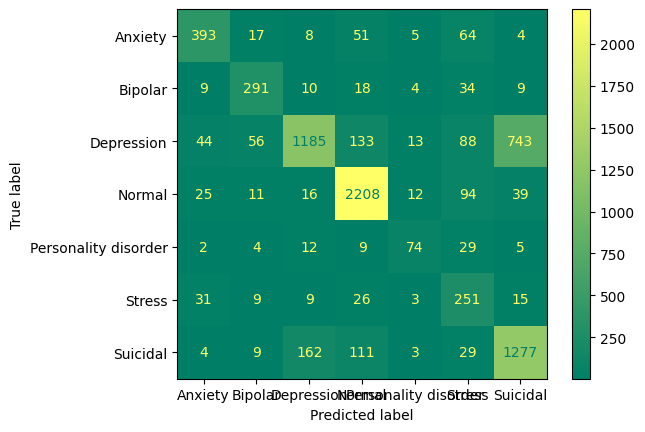

In [21]:
plot_confusion_matrix(pipeline, X_val, y_val)

After careful examination of the above confusion matrix, we can clearly see that our linear model
has a particularly hard time separating "Depression" from "Suicidal", mistakenly voting for "Suicidal"
where it should predict "Depression".

From a non-medical point of view, we're not surprised by model's confusion with these mental states.
Both states are psychologically serious and usually result in similar levels of distress. However,
we'd like to inspect some instances to get a better insight about this.

In [50]:
y_pred = pipeline.predict(X_val)
clf = pipeline.named_steps["classifier"]

cond = (y_val == "Depression") & (y_pred == "Suicidal")
samples = list(X_val.loc[cond][:5].values)

We've already seen in our raw data inspection notebook that some user statements are very long,
so we'll examine items one by one.

### Example 1 (predicted : Suicidal, actual : Depression)

In [52]:
samples[0]

'not much to say honestly i need help i am suffocated and depressed n family friends well ... for them i throw tantrums i am really in a bad place mentally n emotionally n if it is asked what is the reason ???... i cannot just say one or two ... for precisely there are so manycounselling treatment again it is not an option here earlier i had posted about the whole situation but now it is just getting worse with every passing dayi am barely keeping up with myself n noo i am not suicidal i am just standing in the darkfamily friends love never worked for me i want to get out of this mess and to be me againsuggestions advices are much needed a cry for help'

**Analysis**

If we ignore several obvious preprocessing bugs (missing space between two words), the above sample
contains both "depressed" and "suicidal", so the latter (suicidal) may have ended up *looking*
more important.

### Example 2 (predicted : Suicidal, actual : Depression)

In [53]:
samples[1]

'i pay rent i have other bills i have been just diminishing my savings i got a job at a clinic recently which will help me not feel so useless but as soon as i got hired i was hit with a wave of "what even is the point i have so many goals and aspirations but i cannot do a single one unless i magically get money i cannot travel because i cannot afford a decent car i cannot afford college i can barely pay my bare minimum bills as is my body dismorphia has slowly been getting worse and worse too i gag when i see myself now it has kept me from doing things i want to do i am disgusting i always thought dysmorphia was for skinny girls who thought they were fat but turns out it can be for fat girls who are so ashamed of how they look it impacts their entire lifethe only thing saving me right now is my best friend but that sort of thing can only last so long i am so jealous of everyone around me who have so many people that can help them they have so many opportunities i feel like i am never 

**Analysis**

Looking at the above sample, two things stand out as the possible reasons for
model misclassification :
- One occurence of the word "suicide"
- Several occurences of the word "cannot", which frequently appears in suicidal talk (e.g. I cannot take it anymore, I cannot go on with this life, etc.) 

### Example 3 (predicted : Suicidal, actual : Depression)

In [54]:
samples[2]

'i feel that everyone suffers worse than me and have less than i do yet it does not change my outlook on my own life knowing makes me feel that i am not aloud to complain as my problems are not as bad i have been told this from my mother and it hurts because she is right and i have nothing to say for it i am so weak in both body and mind and despite having bigger things to worry about all i want is to be loved to be held with a warm embrace as my tears gently fall from my face it is not going to happen though nobody is going to want me for myself when there are better choices than ii am trying to make friends online but it is very hard as people have there own groups and stop talking to me after awhile i am scared to speak to anyone in person out of fear that someone will see me as a creep it is how i view myself i have been addicted to porn for so long it is as if people can see the disgusting things i have done and watched just by looking at me i know they cannot but that fear creeps

**Analysis**

This is probably one of the longer statements in our dataset. Although none of the words
"suicide" or "suicidal" appears in the text, the sheer length of the text may be the main
cause of model confusion. Additionally, even a human will have a hard time coming up with
the correct label for this text.

### Example 4 (predicted : Suicidal, actual : Depression)

In [55]:
samples[3]

'i hate thinking that money will make me happy i am always daydreaming of being independent living alone on a apartment for myself playing videogames after work going and inviting friends to drink sigh but of course i am depressed lazy and uselesscovid only made it worse i was about to buy me this console last year to see if that could give me some of the happiness i am looking for but i had to spend the money i saved to prepare myself for the pandemic and help my familyi just want to take my backpack run away and start a new life but i know i will not make it fari wonder if i will ever do something with my life or i will just rot away in my parents house too poor too be happy'

### Example 5 (predicted : Suicidal, actual : Depression)

In [56]:
samples[4]

'i am struggling to keep going i think it is easier talking to strangers then telling people i know how i feel i am in a bad place right now but i am trying so hard to not give in i used to be so different but that seems like a different lifetime i still have hope things will get better but the hope dwindles every day will someone talk to me'

**Analysis**

This one looks particularly tricky, because at the first glance it is very similar
to someone thinking about suicide (struggling to keep going, in a bad place, trying
so hard not to give in)

It's quite possible that frequent occurences of words normally associated with suicidal
people may have confused our model.

## Model performance by class

In [22]:
y_pred = pipeline.predict(X_val)
clf = pipeline.named_steps["classifier"]
conf_mat = confusion_matrix(y_val, y_pred, labels=clf.classes_, normalize=None)
conf_mat

array([[ 393,   17,    8,   51,    5,   64,    4],
       [   9,  291,   10,   18,    4,   34,    9],
       [  44,   56, 1185,  133,   13,   88,  743],
       [  25,   11,   16, 2208,   12,   94,   39],
       [   2,    4,   12,    9,   74,   29,    5],
       [  31,    9,    9,   26,    3,  251,   15],
       [   4,    9,  162,  111,    3,   29, 1277]])

### Precision

In [33]:
df_precision = []
for i in range(conf_mat.shape[1]):
    values = conf_mat[:, i].flatten()
    precision = round(values.max() * 100 / values.sum(), 4)
    df_precision.append(pd.Series({ "Precision": precision }, name=clf.classes_[i]))

df_precision = pd.DataFrame(df_precision)
df_precision.sort_values(by="Precision", ascending=False)

,Precision
Normal,86.3850
Depression,84.5221
Anxiety,77.3622
Bipolar,73.2997
Personality disorder,64.9123
Suicidal,61.0421
Stress,42.6146


### Recall

In [34]:
df_recall = []
for i in range(conf_mat.shape[0]):
    values = conf_mat[i, :].flatten()
    recall = round(values.max() * 100 / values.sum(), 4)
    df_recall.append(pd.Series({ "Recall": recall }, name=clf.classes_[i]))

df_recall = pd.DataFrame(df_recall)
df_recall.sort_values(by="Recall", ascending=False)

,Recall
Normal,91.8087
Suicidal,80.0627
Bipolar,77.6000
Stress,72.9651
Anxiety,72.5092
Personality disorder,54.8148
Depression,52.3873
